# TravClan Business Analyst Internship Assignment
## Hotel Booking EDA & Business Insights

## 1. Import Libraries and Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize']=(8,5)

df=pd.read_csv('Hotel_bookings_cleaned.csv')

df.head()


,customer_id,property_id,city,star_rating,booking_date,check_in_date,check_out_date,room_type,num_rooms_booked,stay_type,...,payment_method,refund_status,refund_amount,channel_of_booking,booking_status,travel_date,cashback,coupon_redeem,Coupon USed?,stay_length
0,492,3,San Francisco,4,2024-04-01,2024-05-24,2024-05-26,Standard,1,Leisure,...,PayPal,Yes,369.648995,Web,Confirmed,2024-03-04,5.374694,0.000000,No,2.0
1,180,3,Dallas,3,2024-04-01,2024-05-10,2024-05-17,Deluxe,1,Leisure,...,Bank Transfer,Yes,492.505903,Web,Confirmed,2024-07-19,7.161033,0.000000,No,7.0
2,50,5,Dallas,3,2024-04-01,2024-05-31,2024-06-05,Deluxe,1,Business,...,Debit Card,Yes,0.000000,iOS,Confirmed,2024-03-22,0.000000,0.000000,No,5.0
3,294,3,Orlando,4,2024-04-01,2024-04-18,2024-04-24,Deluxe,3,Leisure,...,Bank Transfer,Yes,545.541516,Android,Confirmed,2024-11-24,7.932170,24.500442,Yes,6.0
4,40,5,Seattle,5,2024-04-01,NaN,NaN,Deluxe,1,Leisure,...,Debit Card,Yes,211.367602,Web,Cancelled,2024-03-02,0.000000,0.000000,No,NaN


## 2. Dataset Overview

In [3]:
print('Rows, Columns:',df.shape)
df.info()


Rows, Columns: (30000, 25)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         30000 non-null  int64  
 1   property_id         30000 non-null  int64  
 2   city                30000 non-null  object 
 3   star_rating         30000 non-null  int64  
 4   booking_date        30000 non-null  object 
 5   check_in_date       24532 non-null  object 
 6   check_out_date      24532 non-null  object 
 7   room_type           30000 non-null  object 
 8   num_rooms_booked    30000 non-null  int64  
 9   stay_type           30000 non-null  object 
 10  booking_channel     30000 non-null  object 
 11  booking_value       30000 non-null  float64
 12  costprice           30000 non-null  int64  
 13  markup              30000 non-null  int64  
 14  selling_price       30000 non-null  int64  
 15  payment_method      30000 

## 3. Data Quality Check

In [6]:
date_cols=['booking_date','check_in_date','check_out_date','travel_date']

for col in date_cols:
    df[col]=pd.to_datetime(df[col],errors='coerce')

df[date_cols].dtypes


booking_date      datetime64[ns]
check_in_date     datetime64[ns]
check_out_date    datetime64[ns]
travel_date       datetime64[ns]
dtype: object

## 5. Booking Status Distribution

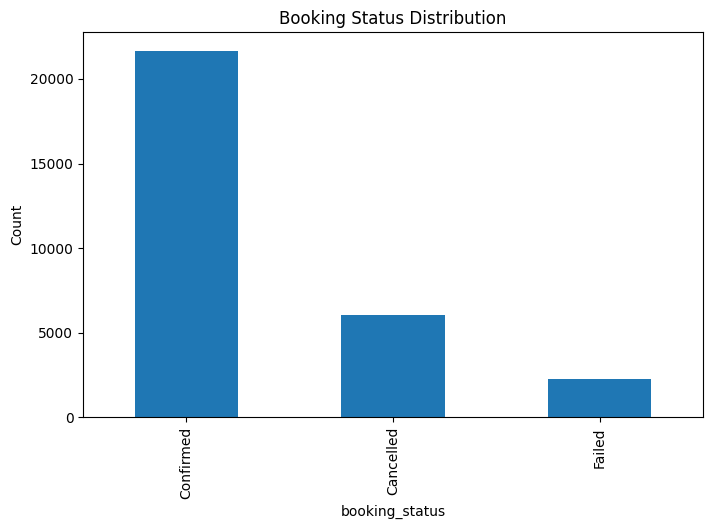

booking_status
Confirmed    21672
Cancelled     6070
Failed        2258
Name: count, dtype: int64

In [7]:
status=df['booking_status'].value_counts()

status.plot(kind='bar')
plt.title('Booking Status Distribution')
plt.ylabel('Count')
plt.show()

status


### Insight
Determine percentage of confirmed, cancelled and failed bookings.

## 6. Booking Channel Analysis

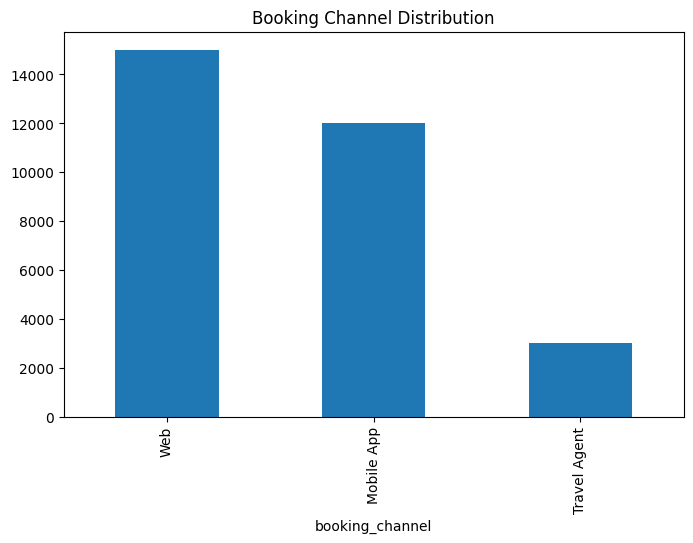

booking_channel
Web             15001
Mobile App      12009
Travel Agent     2990
Name: count, dtype: int64

In [8]:
channel=df['booking_channel'].value_counts()

channel.plot(kind='bar')
plt.title('Booking Channel Distribution')
plt.show()

channel


### Insight
Identify which booking channel contributes maximum bookings.

## 7. Room Type Analysis

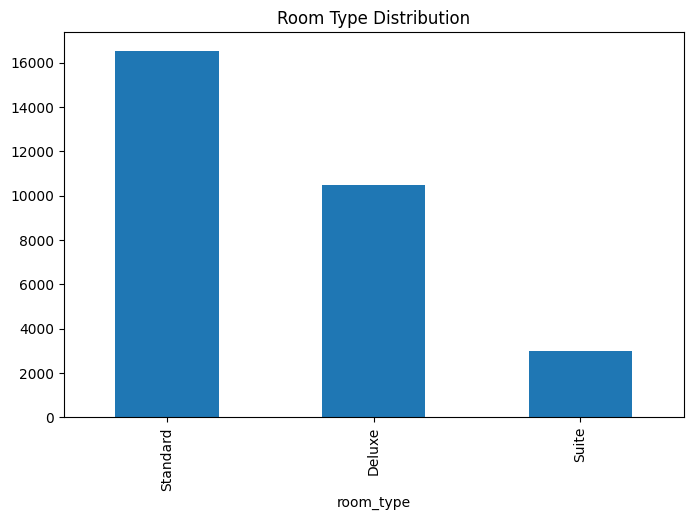

room_type
Standard    16552
Deluxe      10478
Suite        2970
Name: count, dtype: int64

In [9]:
room=df['room_type'].value_counts()

room.plot(kind='bar')
plt.title('Room Type Distribution')
plt.show()

room


### Insight
Identify customer preference for room categories.

## 8. Star Rating Analysis

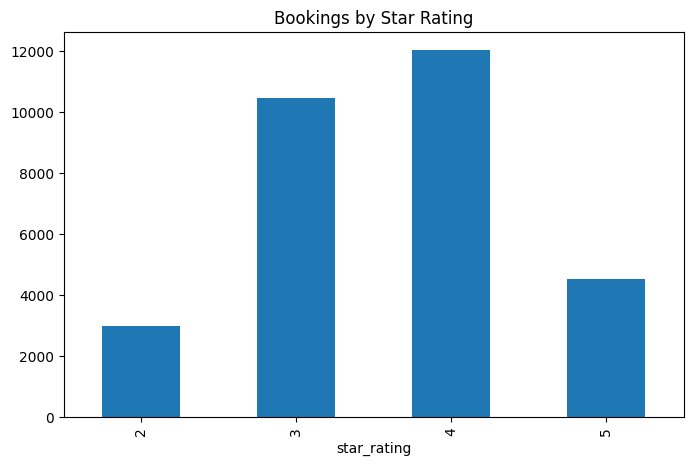

star_rating
2     2995
3    10460
4    12034
5     4511
Name: count, dtype: int64

In [10]:
star=df['star_rating'].value_counts().sort_index()

star.plot(kind='bar')
plt.title('Bookings by Star Rating')
plt.show()

star


### Insight
Understand demand across hotel categories.

## 9. Stay Type Analysis

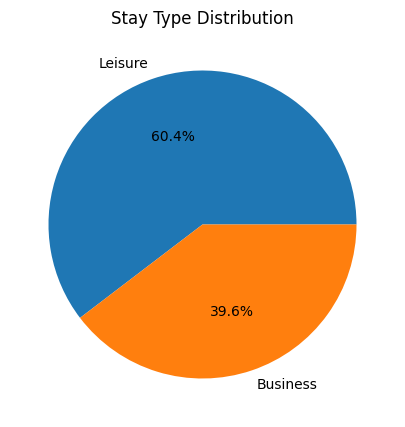

stay_type
Leisure     18110
Business    11890
Name: count, dtype: int64

In [11]:
stay=df['stay_type'].value_counts()

stay.plot(kind='pie',autopct='%1.1f%%')
plt.title('Stay Type Distribution')
plt.ylabel('')
plt.show()

stay


### Insight
Compare Leisure vs Business travel demand.

## 10. Revenue Analysis

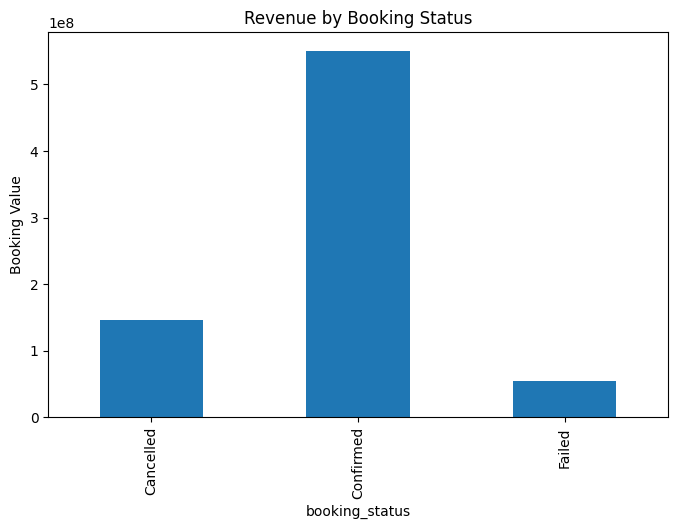

booking_status
Cancelled    1.468349e+08
Confirmed    5.508035e+08
Failed       5.477741e+07
Name: booking_value, dtype: float64

In [12]:
df.groupby('booking_status')['booking_value'].sum().plot(kind='bar')

plt.title('Revenue by Booking Status')
plt.ylabel('Booking Value')
plt.show()

df.groupby('booking_status')['booking_value'].sum()


### Insight
Measure revenue generated and revenue leakage due to cancellations.

## 11. Profitability Analysis

In [13]:
df.groupby('booking_channel')[['booking_value','costprice','markup','selling_price']].mean()


,booking_value,costprice,markup,selling_price
booking_channel,,,,
Mobile App,21351.285716,22478.606045,6943.901074,29422.507120
Travel Agent,24453.972990,22439.272910,6931.740468,29371.013378
Web,28190.840225,22612.213652,6985.168989,29597.382641


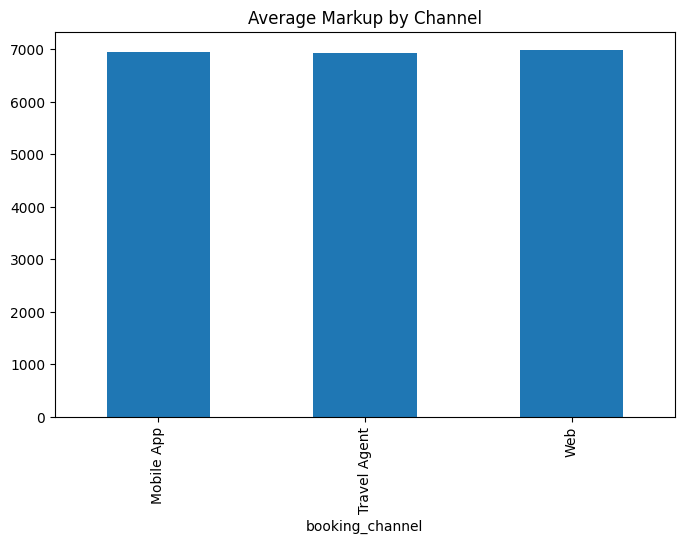

In [14]:
df.groupby('booking_channel')['markup'].mean().plot(kind='bar')

plt.title('Average Markup by Channel')
plt.show()


### Insight
Identify most profitable booking channels.

## 12. Cancellation Analysis by Channel

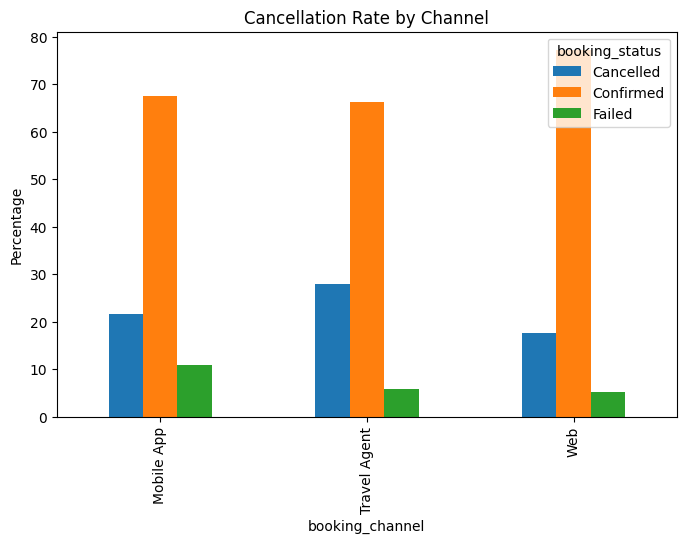

booking_status,Cancelled,Confirmed,Failed
booking_channel,,,
Mobile App,21.558831,67.541011,10.900158
Travel Agent,27.926421,66.187291,5.886288
Web,17.638824,77.208186,5.152990


In [15]:
cancel_channel=pd.crosstab(
    df['booking_channel'],
    df['booking_status'],
    normalize='index'
)*100

cancel_channel.plot(kind='bar')

plt.title('Cancellation Rate by Channel')
plt.ylabel('Percentage')
plt.show()

cancel_channel


### Root Cause Question
Why do some channels perform better than others?

## 13. Cancellation Analysis by Room Type

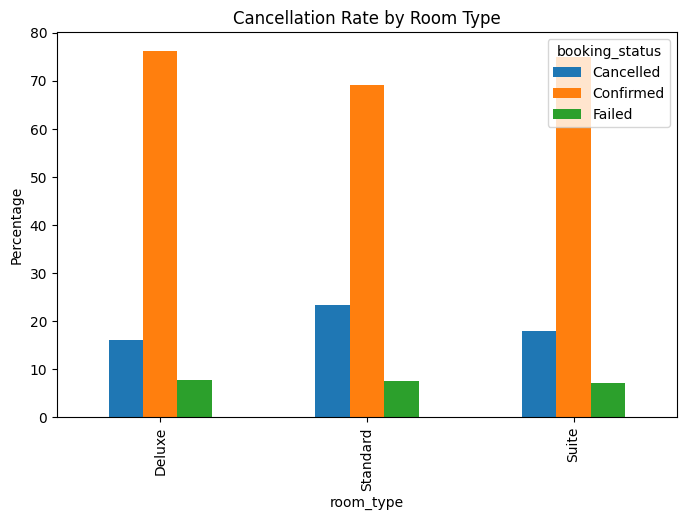

booking_status,Cancelled,Confirmed,Failed
room_type,,,
Deluxe,16.024050,76.312273,7.663676
Standard,23.302320,69.188014,7.509667
Suite,17.979798,74.882155,7.138047


In [16]:
cancel_room=pd.crosstab(
    df['room_type'],
    df['booking_status'],
    normalize='index'
)*100

cancel_room.plot(kind='bar')

plt.title('Cancellation Rate by Room Type')
plt.ylabel('Percentage')
plt.show()

cancel_room


### Root Cause Question
Which room categories have higher cancellation behaviour?

## 14. Cancellation Analysis by Star Rating

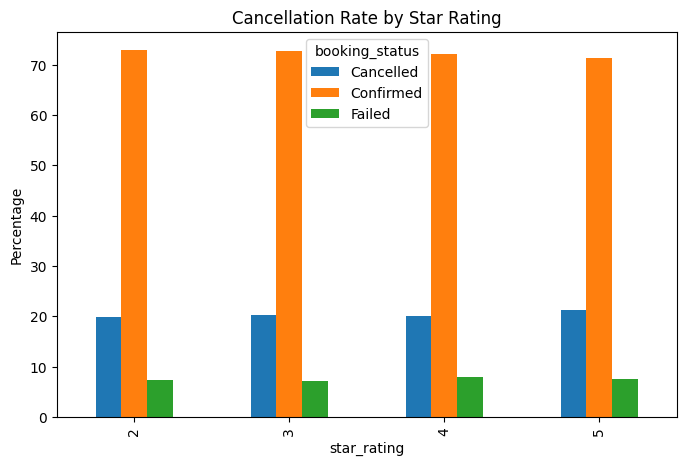

booking_status,Cancelled,Confirmed,Failed
star_rating,,,
2,19.766277,72.854758,7.378965
3,20.200765,72.648184,7.151052
4,19.993352,72.112348,7.894299
5,21.259144,71.225892,7.514963


In [17]:
cancel_star=pd.crosstab(
    df['star_rating'],
    df['booking_status'],
    normalize='index'
)*100

cancel_star.plot(kind='bar')

plt.title('Cancellation Rate by Star Rating')
plt.ylabel('Percentage')
plt.show()

cancel_star


### Root Cause Question
Do premium hotels experience different cancellation patterns?

## 15. Booking Value by Room Type

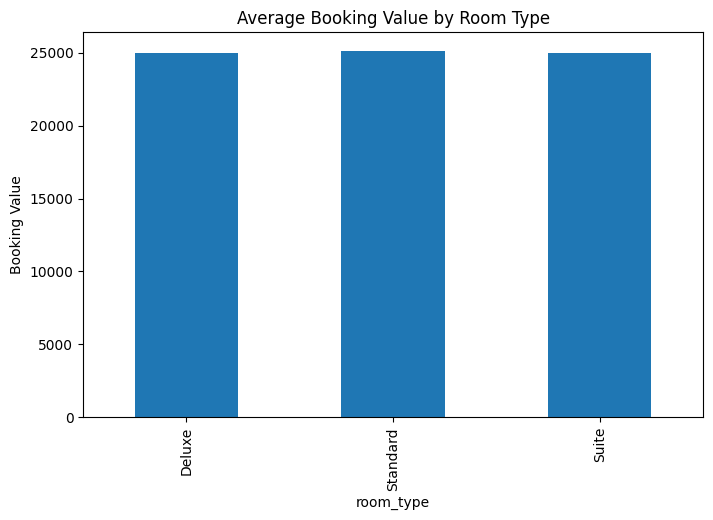

In [18]:
df.groupby('room_type')['booking_value'].mean().plot(kind='bar')

plt.title('Average Booking Value by Room Type')
plt.ylabel('Booking Value')
plt.show()


### Insight
Understand customer spending patterns.

## 16. Monthly Booking Trend

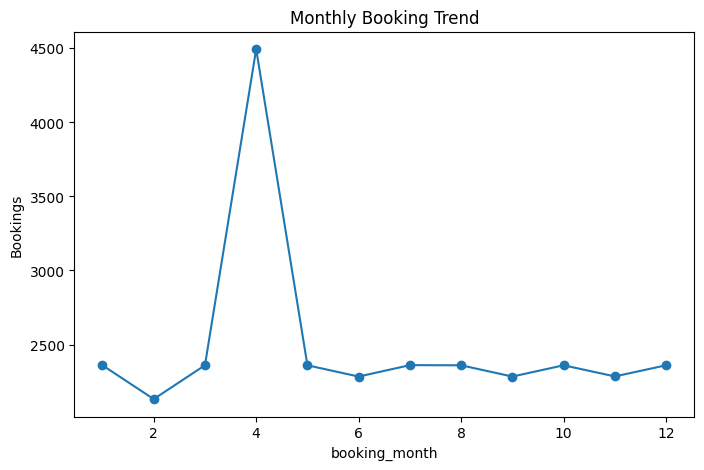

booking_month
1     2360
2     2132
3     2360
4     4494
5     2360
6     2284
7     2361
8     2360
9     2284
10    2360
11    2285
12    2360
dtype: int64

In [19]:
df['booking_month']=df['booking_date'].dt.month

monthly=df.groupby('booking_month').size()

monthly.plot(kind='line',marker='o')

plt.title('Monthly Booking Trend')
plt.ylabel('Bookings')
plt.show()

monthly


### Root Cause Question
Identify seasonality and demand peaks.

## 17. Monthly Revenue Trend

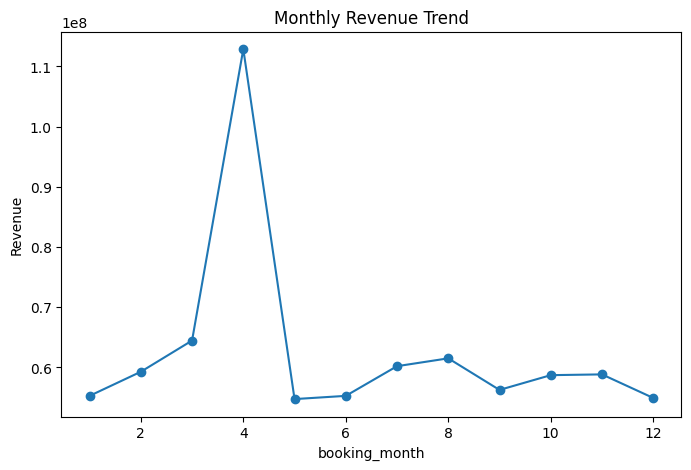

booking_month
1     5.528121e+07
2     5.928334e+07
3     6.446651e+07
4     1.128735e+08
5     5.474528e+07
6     5.527916e+07
7     6.020926e+07
8     6.151278e+07
9     5.626658e+07
10    5.871826e+07
11    5.884617e+07
12    5.493369e+07
Name: booking_value, dtype: float64

In [20]:
monthly_revenue=df.groupby('booking_month')['booking_value'].sum()

monthly_revenue.plot(kind='line',marker='o')

plt.title('Monthly Revenue Trend')
plt.ylabel('Revenue')
plt.show()

monthly_revenue


### Insight
Check seasonal impact on revenue.

## 18. Refund Analysis

In [21]:
df.groupby('refund_status')['refund_amount'].sum()


refund_status
No     0.000000e+00
Yes    9.628151e+06
Name: refund_amount, dtype: float64

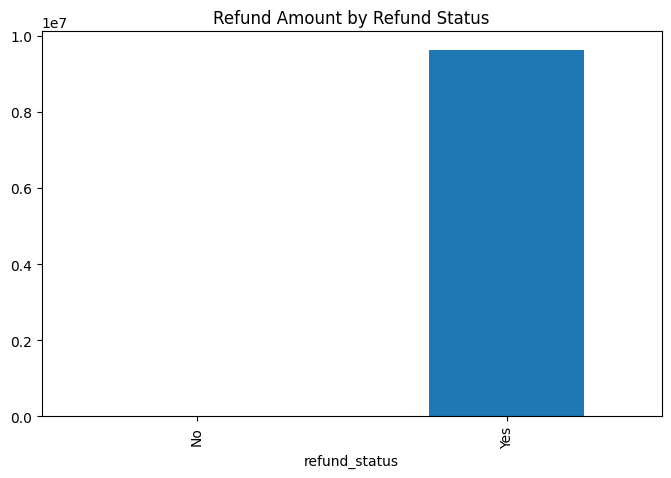

In [22]:
df.groupby('refund_status')['refund_amount'].sum().plot(kind='bar')

plt.title('Refund Amount by Refund Status')
plt.show()


### Insight
Measure revenue lost due to refunds.

## 19. Coupon & Cashback Analysis

In [23]:
coupon_col='Coupon USed?'

pd.crosstab(
    df[coupon_col],
    df['booking_status']
)


booking_status,Cancelled,Confirmed,Failed
Coupon USed?,,,
No,4782,17267,1758
Yes,1288,4405,500


In [24]:
df.groupby('Coupon USed?')['booking_value'].mean()


Coupon USed?
No     25167.898275
Yes    24744.648699
Name: booking_value, dtype: float64

### Insight
Evaluate effectiveness of coupons and cashback.

## 20. Payment Method Analysis

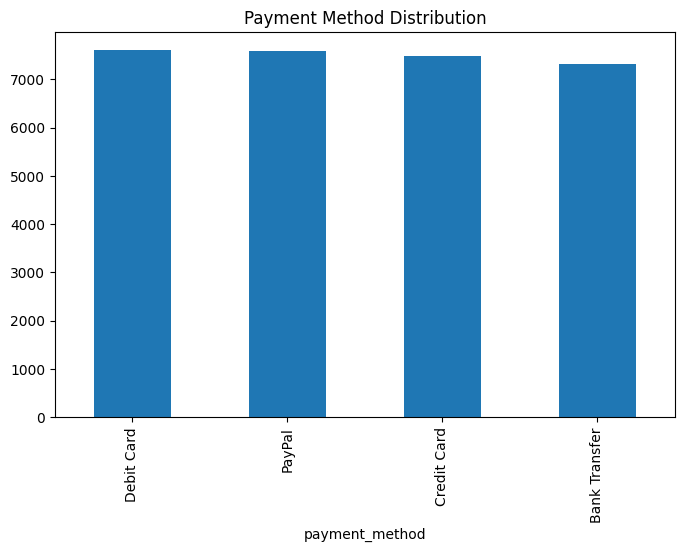

In [25]:
df['payment_method'].value_counts().plot(kind='bar')

plt.title('Payment Method Distribution')
plt.show()


### Insight
Identify preferred payment methods.

## 21. Correlation Heatmap

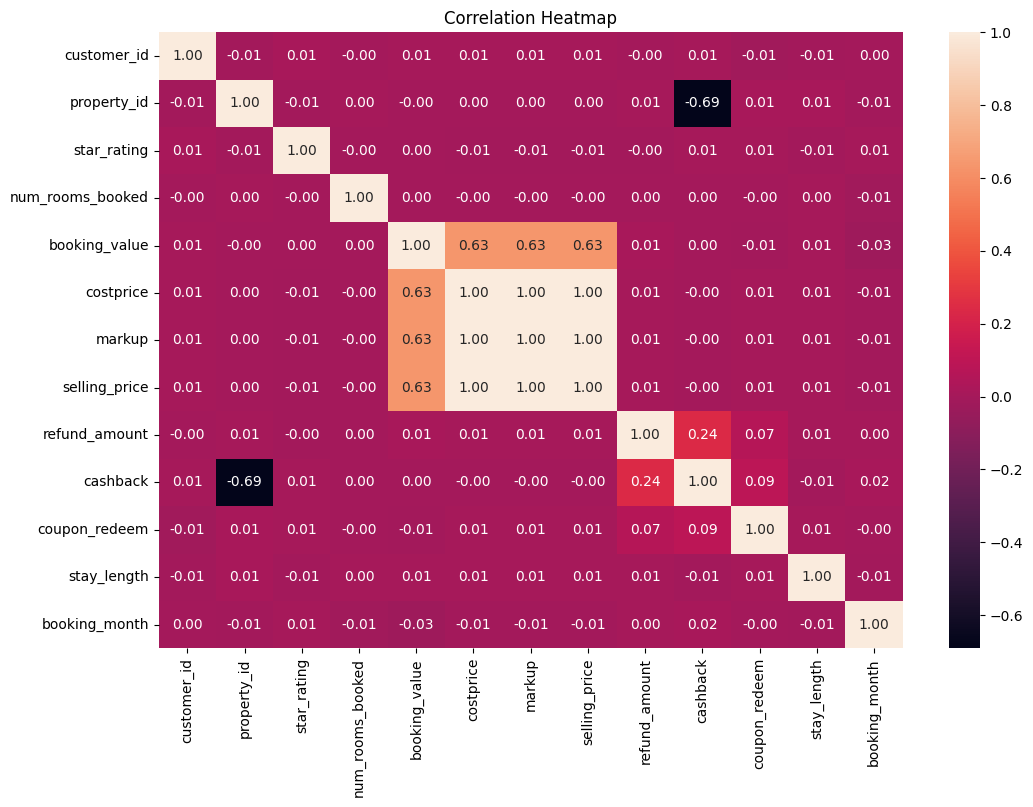

In [26]:
numeric_df=df.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()
